[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter10_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 10: Long memory and rough volatility

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 10; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- Realised measures: the Oxford-Man Institute's realized library v0.3 (six equity indices, 5-minute returns, January 2000 - February 2022; downloaded by `read_omi` from the Internet Archive copy, not redistributed) and our Bitcoin measures from Binance one-minute prices (2018-2026), in `data/realized` of the ATS repository.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The numpy engine of Chapter 10, the data helpers and the functions of the solved tasks.

In [ ]:
import functools
from scipy import integrate, signal, special
from scipy.signal import lfilter
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                 if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
OMI_NAMES = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', '.FTSE': 'FTSE 100', '.N225': 'Nikkei 225', '.STOXX50E': 'Euro Stoxx 50', '.FCHI': 'CAC 40'}
LAGS = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50)
QS = (0.5, 1.0, 1.5, 2.0, 3.0)
A_BW = 0.65
FC = {'window': 1000, 'refit': 20, 'horizons': (1, 5, 22)}
VOL_ASSETS = {'sp500': '2000-01-01', 'bet': '2000-01-01', 'btc': '2015-01-01'}
ASSETS_D = {'sp500': ('S&P 500', '2000-01-01', '.SPX'), 'dax': ('DAX', '2000-01-01', '.GDAXI'), 'bet': ('BET', '2000-01-01', None), 'eurron': ('EUR/RON', '2005-07-01', None), 'btc': ('Bitcoin', '2014-09-17', 'btc')}
FC_ASSETS = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', 'btc': 'Bitcoin'}
AI_MEASURES = {'omi': ['rv5', 'rv10', 'bv', 'medrv', 'rk_parzen'], 'btc': ['rv1', 'rv5', 'rv15', 'bv5', 'rk1']}
_MEM = {}
A1 = {'d': 0.3, 'lags': (1, 10, 100), 'n': 1000}
A2 = {'d': 0.4, 'K': 5, 'k_big': 100, 'trunc': 1000}
A3 = {'n': 5000, 'a': 0.65, 'd_hat': 0.45}
A4 = {'phi': 0.5, 'n': 5000, 'a': 0.8}
A5 = {'Hs': (0.1, 0.3, 0.7), 'lag': 22}
A6 = {'H': 0.1, 'nu': 0.3, 'hs': (1, 5, 22), 'K': 500}
A7 = {'H': 0.3}
A8 = {'mu': 1.0, 'sigma': 1.0, 'q': 0.995, 'lags': (1, 100, 500)}
import pandas as pd


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def omi(symbol='.SPX', col='rv5'):
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): one index and one measure,
    daily, in %^2 (5-minute realised variance by default); non-positive days dropped."""
    if 'omi' not in _MEM:
        _MEM['omi'] = read_omi()
    d = _MEM['omi']
    s = d[d['symbol'] == symbol].set_index('date').sort_index()[col] * 1e4
    return s[s > 0].dropna().rename(OMI_NAMES[symbol])


def binance(col='rv5', coin='btc'):
    """Our daily realised measures of Bitcoin from Binance one-minute prices (UTC days, %^2)."""
    if 'bin' not in _MEM:
        _MEM['bin'] = read_realized('binance_daily_realized.csv', parse_dates=['date'], index_col='date')
    s = _MEM['bin'][f'{coin}_{col}']
    return s[s > 0].dropna().rename('Bitcoin')


def rv_series(name, col=None):
    """Daily realised variance (%^2) of a named asset: OMI indices (rv5) or Bitcoin (Binance, rv5)."""
    if name == 'btc':
        return binance(col or 'rv5')
    return omi(name, col or 'rv5')


def parkinson(name, start='2000-01-01'):
    """Parkinson (1980) range-based daily variance (ln H - ln L)^2 / (4 ln 2), in %^2; zero-range days dropped."""
    t = load_ohlc(name, start=start)
    v = 1e4 * (np.log(t['high']) - np.log(t['low'])) ** 2 / (4 * np.log(2))
    return v[v > 0]


def returns(name, start='2000-01-01'):
    """Daily log returns in % (EUR/RON: BNR reference rate; Bitcoin: 7 days a week)."""
    return log_returns(name, start=start).dropna()


def sample_acf(x, K):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    f = np.fft.rfft(x, 2 * n)
    a = np.fft.irfft(f * np.conj(f))[:K + 1]
    return a / a[0]


def inflation(country):
    """Monthly inflation, % annualised: US CPI (FRED CPIAUCSL, seasonally adjusted), 1960 onwards; Romania: HICP
    (Eurostat prc_hicp_minr, index 2025 = 100, not adjusted), 1997 onwards, monthly means removed (seasonal dummies)."""
    if country == 'us':
        p = read_fred('CPIAUCSL').loc['1959-12-01':]
        return (1200 * np.log(p).diff()).dropna().rename('US')
    p = read_eurostat('prc_hicp_minr', 'M.I25.TOTAL.RO').loc['1996-12-01':]
    x = (1200 * np.log(p).diff()).dropna()
    sea = x.groupby(x.index.month).transform('mean') - x.mean()
    return (x - sea).rename('Romania')


def frac_weights(d, n):
    """Coefficients pi_k of (1 - L)^d, k = 0..n-1: pi_0 = 1, pi_k = pi_{k-1}(k - 1 - d)/k."""
    w = np.empty(n)
    w[0] = 1.0
    k = np.arange(1, n)
    w[1:] = np.cumprod((k - 1 - d) / k)
    return w


def frac_diff(x, d):
    """Type II fractional difference (1 - L)^d x_t with x_t = 0 for t <= 0, by FFT convolution; works on columns."""
    x = np.asarray(x, float)
    n = x.shape[0]
    w = frac_weights(d, n)
    nfft = 1 << (2 * n - 1).bit_length()
    W = np.fft.rfft(w, nfft)
    if x.ndim == 1:
        return np.fft.irfft(np.fft.rfft(x, nfft) * W, nfft)[:n]
    return np.fft.irfft(np.fft.rfft(x, nfft, axis=0) * W[:, None], nfft, axis=0)[:n]


def arfima_acov(d, n, sigma2=1.0):
    """Autocovariances gamma(0..n-1) of ARFIMA(0, d, 0), |d| < 1/2 (Hosking 1981)."""
    g = np.empty(n)
    g[0] = sigma2 * special.gamma(1 - 2 * d) / special.gamma(1 - d) ** 2
    k = np.arange(1, n)
    g[1:] = g[0] * np.cumprod((k - 1 + d) / (k - d))
    return g


def arfima_acf(d, n):
    return arfima_acov(d, n) / arfima_acov(d, 1)[0]


def fgn_acov(H, n):
    """Autocovariances of fractional Gaussian noise with unit variance: (|k+1|^2H - 2|k|^2H + |k-1|^2H)/2."""
    k = np.arange(n, dtype=float)
    return 0.5 * (np.abs(k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))


def circulant_sim(acov, rng, n_paths=1):
    """Exact simulation of a stationary Gaussian series with autocovariances acov[0..n-1] by circulant embedding
    (Davies and Harte 1987; Dietrich and Newsam 1997). Returns an (n_paths, n) array."""
    acov = np.asarray(acov, float)
    n = len(acov)
    c = np.concatenate([acov, acov[-2:0:-1]])
    lam = np.fft.fft(c).real
    if lam.min() < -1e-8 * lam.max():
        raise ValueError('circulant embedding is not non-negative definite')
    lam = np.clip(lam, 0, None)
    M = len(c)
    k = (n_paths + 1) // 2
    Z = rng.standard_normal((k, M)) + 1j * rng.standard_normal((k, M))
    Y = np.fft.fft(np.sqrt(lam / M) * Z, axis=1)
    out = np.vstack([Y.real[:, :n], Y.imag[:, :n]])
    return out[:n_paths]


def circulant_eigs(acov):
    c = np.concatenate([acov, acov[-2:0:-1]])
    return np.fft.fft(c).real


def sim_arfima(n, d, rng, phi=0.0, theta=0.0, burn=500, n_paths=1):
    """ARFIMA(1, d, 1) paths: exact ARFIMA(0, d, 0) by circulant embedding, then the ARMA filter (burn-in dropped).
    For d >= 1/2 the series is the partial sum of an ARFIMA(0, d - 1, 0)."""
    if d >= 0.5:
        x = sim_arfima(n, d - 1, rng, phi, theta, burn, n_paths)
        return np.cumsum(x, axis=1)
    x = circulant_sim(arfima_acov(d, n + burn), rng, n_paths)
    if phi or theta:
        x = signal.lfilter([1.0, theta], [1.0, -phi], x, axis=1)
    return x[:, burn:]


def fbm(n, H, rng, n_paths=1, T=1.0):
    """Fractional Brownian motion on a grid of n steps over [0, T] (cumulated exact fGn); B_0 = 0 included."""
    g = circulant_sim(fgn_acov(H, n), rng, n_paths) * (T / n) ** H
    return np.hstack([np.zeros((n_paths, 1)), np.cumsum(g, axis=1)])


def hybrid_rl(n, H, rng, n_paths=1, T=1.0, kappa=1):
    """Riemann-Liouville process X(t) = int_0^t (t - s)^(H - 1/2) dW(s) on n steps over [0, T].
    kappa = 1: the hybrid scheme of Bennedsen, Lunde and Pakkanen (2017) (exact Wiener integral on the first cell,
    optimal evaluation points b_k on the others); kappa = 0: the plain forward Riemann sum (kernel at k/n)."""
    a = H - 0.5
    dt = T / n
    k = np.arange(1, n + 1, dtype=float)
    if kappa == 1:
        cov = np.array([[dt, dt ** (a + 1) / (a + 1)], [dt ** (a + 1) / (a + 1), dt ** (2 * a + 1) / (2 * a + 1)]])
        L = np.linalg.cholesky(cov)
        Z = rng.standard_normal((n_paths, n, 2)) @ L.T
        dW, first = Z[..., 0], Z[..., 1]
        b = ((k ** (a + 1) - (k - 1) ** (a + 1)) / (a + 1)) ** (1 / a)
        g = (b * dt) ** a
        g[0] = 0.0                                  # the first cell is the exact integral
    else:
        dW = rng.standard_normal((n_paths, n)) * np.sqrt(dt)
        first = 0.0
        g = (k * dt) ** a
    nfft = 1 << (2 * n - 1).bit_length()
    conv = np.fft.irfft(np.fft.rfft(dW, nfft, axis=1) * np.fft.rfft(g, nfft)[None, :], nfft, axis=1)[:, :n]
    X = conv + first
    return np.hstack([np.zeros((n_paths, 1)), X])


def periodogram(x, m=None, demean=True):
    """Periodogram I(lambda_j) = |sum_t x_t e^{-i lambda_j t}|^2 / (2 pi n) at lambda_j = 2 pi j / n, j = 1..m."""
    x = np.asarray(x, float)
    n = len(x)
    X = np.fft.fft(x - x.mean() if demean else x)
    m = m or n // 2
    j = np.arange(1, m + 1)
    return 2 * np.pi * j / n, np.abs(X[1:m + 1]) ** 2 / (2 * np.pi * n)


def bandwidth(n, a):
    return int(np.floor(n ** a))


def gph(x, m):
    """Log-periodogram (GPH) estimator: OLS of log I on -log(4 sin^2(lambda/2)); returns (d, asymptotic SE pi/sqrt(24m),
    OLS SE)."""
    lam, I = periodogram(x, m)
    X = -np.log(4 * np.sin(lam / 2) ** 2)
    Y = np.log(I)
    Xc = X - X.mean()
    d = Xc @ (Y - Y.mean()) / (Xc @ Xc)
    u = Y - Y.mean() - d * Xc
    return float(d), float(np.pi / np.sqrt(24 * m)), float(np.sqrt(u @ u / (m - 2) / (Xc @ Xc)))


def lw_objective(d, lam, I):
    return np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))


def local_whittle(x, m, lo=-0.49, hi=1.49):
    """Local Whittle (Gaussian semiparametric) estimator of Robinson (1995); SE 1/(2 sqrt(m))."""
    lam, I = periodogram(x, m)
    grid = np.linspace(lo, hi, 41)
    g0 = grid[np.argmin([lw_objective(d, lam, I) for d in grid])]
    r = optimize.minimize_scalar(lw_objective, bounds=(max(lo, g0 - 0.06), min(hi, g0 + 0.06)), args=(lam, I),
                                 method='bounded', options=dict(xatol=1e-6))
    return float(r.x), float(1 / (2 * np.sqrt(m)))


def shimotsu_weight(d):
    """Weight on the sample mean in the unknown-mean ELW of Shimotsu (2010): 1 for d <= 1/2, 0 for d >= 3/4."""
    if d <= 0.5:
        return 1.0
    if d >= 0.75:
        return 0.0
    return 0.5 * (1 + np.cos(4 * np.pi * d))


def elw_objective(d, x, m, mean=True):
    n = len(x)
    if mean:
        w = shimotsu_weight(d)
        x = x - (w * x.mean() + (1 - w) * x[0])
    v = frac_diff(x, d)
    V = np.fft.fft(v)
    j = np.arange(1, m + 1)
    lam = 2 * np.pi * j / n
    I = np.abs(V[1:m + 1]) ** 2 / (2 * np.pi * n)
    return np.log(np.mean(I)) - 2 * d * np.mean(np.log(lam))


def elw(x, m, lo=-0.49, hi=2.0, mean=True):
    """Exact local Whittle estimator (Shimotsu and Phillips 2005) with the unknown-mean correction of Shimotsu (2010);
    consistent and N(d, 1/(4m)) for any d in the search range."""
    x = np.asarray(x, float)
    grid = np.linspace(lo, hi, 51)
    g0 = grid[np.argmin([elw_objective(d, x, m, mean) for d in grid])]
    r = optimize.minimize_scalar(elw_objective, bounds=(max(lo, g0 - 0.06), min(hi, g0 + 0.06)), args=(x, m, mean),
                                 method='bounded', options=dict(xatol=1e-6))
    return float(r.x), float(1 / (2 * np.sqrt(m)))


def lwn(x, m):
    """Local Whittle with additive noise (Hurvich, Moulines and Soulier 2005): f(lambda) = G(lambda^-2d + theta),
    theta >= 0 the noise-to-signal ratio; returns (d, theta)."""
    lam, I = periodogram(x, m)

    def obj(p):
        d, th = p
        g = lam ** (-2 * d) + th
        return np.log(np.mean(I / g)) + np.mean(np.log(g))
    best = None
    for d0 in (0.1, 0.3, 0.5):
        for t0 in (0.0, 1.0, 10.0):
            r = optimize.minimize(obj, [d0, t0], bounds=[(-0.49, 0.99), (0.0, 1e4)], method='L-BFGS-B')
            if best is None or r.fun < best.fun:
                best = r
    return float(best.x[0]), float(best.x[1])


def lbias_constant(phi):
    """Leading bias constant of GPH / local Whittle for ARFIMA(1, d, 0): bias ~ C (m/n)^2 with
    C = -(2 pi^2/9) f*''(0)/f*(0) = (2 pi^2/9) 2 phi/(1 - phi)^2."""
    return 2 * np.pi ** 2 / 9 * 2 * phi / (1 - phi) ** 2


def mse_opt_m(n, C):
    """MSE-optimal bandwidth of local Whittle: bias^2 + 1/(4m) with bias C (m/n)^2 -> m* = (n^4/(16 C^2))^(1/5)."""
    return (n ** 4 / (16 * C ** 2)) ** 0.2


def qu_stat(x, m, eps=0.02):
    """Qu (2011) statistic W = sup_{r in [eps, 1]} |sum_{j <= mr} nu_j (lambda_j^{2d} I_j / G - 1)| / sqrt(sum nu_j^2),
    with d and G the local Whittle estimates on the same m frequencies."""
    lam, I = periodogram(x, m)
    d, _ = local_whittle(x, m)
    G = np.mean(lam ** (2 * d) * I)
    nu = np.log(lam) - np.mean(np.log(lam))
    S = np.cumsum(nu * (lam ** (2 * d) * I / G - 1))
    r0 = max(int(np.floor(eps * m)), 1)
    return float(np.max(np.abs(S[r0 - 1:])) / np.sqrt(nu @ nu)), d


def qu_critical(eps=0.02, n=16384, a=0.7, reps=2000, seed=11):
    """Critical values of the Qu statistic simulated under Gaussian white noise (its null limit does not depend on d)."""
    rng = np.random.default_rng(seed)
    m = bandwidth(n, a)
    W = np.array([qu_stat(rng.standard_normal(n), m, eps)[0] for _ in range(reps)])
    return {str(q): float(np.quantile(W, q)) for q in (0.90, 0.95, 0.99)}


def random_level_shift(n, rng, p=0.005, s_shift=1.0, s_noise=1.0, phi=0.0):
    """Short memory plus random level shifts (Lu and Perron 2010): y = mu_t + u_t, mu_t jumps with probability p."""
    jumps = (rng.random(n) < p) * rng.normal(0, s_shift, n)
    u = signal.lfilter([1.0], [1.0, -phi], rng.normal(0, s_noise, n))
    return np.cumsum(jumps) + u


def fcvar_loglik(X, d, b, r):
    """Concentrated log-likelihood of the FCVAR with k = 0 lags (Johansen and Nielsen 2012),
    Delta^d X_t = alpha beta' L_b Delta^(d-b) X_t + eps_t, L_b = 1 - Delta^b, X demeaned; rank r."""
    Z0 = frac_diff(X, d)
    Z1 = frac_diff(X, d - b) - Z0
    T = X.shape[0]
    S00, S11, S01 = Z0.T @ Z0 / T, Z1.T @ Z1 / T, Z0.T @ Z1 / T
    ll = -T / 2 * np.log(np.linalg.det(S00))
    if r == 0:
        return ll, None
    A = np.linalg.solve(S11, S01.T @ np.linalg.solve(S00, S01))
    ev, V = np.linalg.eig(A)
    o = np.argsort(-ev.real)
    ev, V = ev.real[o], V.real[:, o]
    ll -= T / 2 * np.sum(np.log(1 - ev[:r]))
    beta = V[:, :r]
    beta = beta / beta[0]
    alpha = S01 @ beta @ np.linalg.inv(beta.T @ S11 @ beta)
    return ll, dict(ev=ev, beta=beta, alpha=alpha)


def fcvar_fit(X, dgrid, bstep=0.02):
    """Profile likelihood over (d, b) for ranks 0, 1 and p; trace statistics; estimates at the rank-1 maximum."""
    X = np.asarray(X, float) - np.asarray(X, float).mean(0)
    p = X.shape[1]
    best = {0: (-np.inf, None), 1: (-np.inf, None), p: (-np.inf, None)}
    surf = []
    for d in dgrid:
        l0 = fcvar_loglik(X, d, 0.5 * d, 0)[0]
        if l0 > best[0][0]:
            best[0] = (l0, (d, None))
        for b in np.arange(bstep, d + 1e-9, bstep):
            for r in (1, p):
                ll, _ = fcvar_loglik(X, d, b, r)
                if ll > best[r][0]:
                    best[r] = (ll, (d, b))
                if r == 1:
                    surf.append((d, b, ll))
    d1, b1 = best[1][1]
    _, est = fcvar_loglik(X, d1, b1, 1)
    out = dict(d=d1, b=b1, beta=est['beta'][:, 0].tolist(), alpha=est['alpha'][:, 0].tolist(),
               ll0=best[0][0], ll1=best[1][0], llp=best[p][0], d0=best[0][1][0], dp=best[p][1][0], bp=best[p][1][1],
               surf=np.array(surf))
    out['trace0'] = 2 * (out['llp'] - out['ll0'])
    out['trace1'] = 2 * (out['llp'] - out['ll1'])
    out['p0'] = float(stats.chi2.sf(out['trace0'], p ** 2))
    out['p1'] = float(stats.chi2.sf(out['trace1'], (p - 1) ** 2))
    return out


def nbls(y, x, m):
    """Narrow-band least squares (Robinson 1994): beta = Re sum_{j<=m} I_xy / sum_{j<=m} I_xx."""
    n = len(y)
    Y, Xf = np.fft.fft(y - y.mean()), np.fft.fft(x - x.mean())
    j = np.arange(1, m + 1)
    return float(np.real(np.sum(Xf[j] * np.conj(Y[j]))) / np.sum(np.abs(Xf[j]) ** 2))


def arch_inf_weights(kind, par, K):
    """ARCH(infinity) weights lambda_1..lambda_K of sigma^2_t = omega/(1 - beta) + sum_k lambda_k eps^2_{t-k}.
    FIGARCH(1,d,1) (Baillie, Bollerslev and Mikkelsen 1996): 1 - (1 - beta L)^-1 (1 - phi L)(1 - L)^d;
    HYGARCH (Davidson 2004): the same with (1 - L)^d replaced by 1 + a((1 - L)^d - 1); GARCH(1,1): a L/(1 - beta L)."""
    if kind == 'garch':
        a, beta = par
        return a * beta ** np.arange(K)
    if kind == 'figarch':
        d, phi, beta = par
        amp = 1.0
    else:
        d, phi, beta, amp = par
    w = amp * frac_weights(d, K + 1)
    w[0] += 1 - amp
    bb = np.convolve([1.0, -phi], w)[:K + 1]
    c = signal.lfilter([1.0], [1.0, -beta], bb)
    lam = -c
    lam[0] += 1
    return lam[1:]


def arch_inf_sigma2(e2, const, lam, init=None):
    """sigma^2_t = const + sum_k lambda_k e2_{t-k}, pre-sample e2 set to their mean, by FFT convolution."""
    K, n = len(lam), len(e2)
    pre = np.full(K, e2.mean() if init is None else init)
    z = np.concatenate([pre, e2])
    s = signal.fftconvolve(z, np.concatenate([[0.0], lam]))[K:K + n]
    return const + s


def _t_loglik(e, s2, nu):
    z2 = e ** 2 / s2
    c = special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
    return c - 0.5 * np.log(s2) - (nu + 1) / 2 * np.log1p(z2 / (nu - 2))


def ltm_negll(theta, e, kind, K):
    if kind == 'garch':
        om, a, beta, nu = theta
        if a < 0 or beta < 0 or a + beta >= 0.9999:
            return 1e10
        lam = arch_inf_weights('garch', (a, beta), K)
        const = om / (1 - beta)
    elif kind == 'figarch':
        om, d, phi, beta, nu = theta
        if not (0 < d < 1 and 0 <= phi < 1 and 0 <= beta < 1 and beta - d <= phi):
            return 1e10
        lam = arch_inf_weights('figarch', (d, phi, beta), K)
        const = om / (1 - beta)
    else:
        om, d, phi, beta, amp, nu = theta
        if not (0 < d < 1 and 0 <= phi < 1 and 0 <= beta < 1 and 0 <= amp < 3):
            return 1e10
        lam = arch_inf_weights('hygarch', (d, phi, beta, amp), K)
        const = om / (1 - beta)
    if om <= 0 or nu <= 2.05 or lam.min() < -1e-8:
        return 1e10
    s2 = arch_inf_sigma2(e ** 2, const, lam)
    if s2.min() <= 0:
        return 1e10
    return -np.sum(_t_loglik(e, s2, nu))


def ltm_fit(r, kind='figarch', K=1000):
    """Student t QML of GARCH(1,1), FIGARCH(1,d,1) or HYGARCH on demeaned returns (in %), ARCH(infinity) truncated at K."""
    e = np.asarray(r, float) - np.mean(r)
    v = e.var()
    starts = {'garch': [[0.02 * v, 0.08, 0.90, 6.0], [0.05 * v, 0.12, 0.85, 5.0]],
              'figarch': [[0.02 * v, 0.40, 0.20, 0.50, 6.0], [0.05 * v, 0.30, 0.10, 0.30, 5.0], [0.03 * v, 0.55, 0.30, 0.70, 6.0]],
              'hygarch': [[0.02 * v, 0.40, 0.20, 0.50, 0.95, 6.0], [0.03 * v, 0.55, 0.30, 0.70, 0.80, 5.0]]}[kind]
    best = None
    for s0 in starts:
        r_ = optimize.minimize(ltm_negll, s0, args=(e, kind, K), method='Nelder-Mead',
                               options=dict(maxiter=4000, maxfev=6000, xatol=1e-6, fatol=1e-6))
        if best is None or r_.fun < best.fun:
            best = r_
    k = len(best.x)
    return dict(par=best.x.tolist(), ll=float(-best.fun), bic=float(2 * best.fun + k * np.log(len(e))), k=k)


def variogram(x, lags, q=2.0):
    """m(q, Delta) = mean |x_{t+Delta} - x_t|^q for each lag Delta."""
    x = np.asarray(x, float)
    return np.array([np.mean(np.abs(x[L:] - x[:-L]) ** q) for L in lags])


def gjr_scaling(logsig, lags=tuple(range(1, 51)), qs=(0.5, 1.0, 1.5, 2.0, 3.0)):
    """Gatheral, Jaisson and Rosenbaum (2018): log m(q, Delta) = zeta_q log Delta + c_q; zeta_q = q H;
    H by least squares of zeta_q on q through the origin; nu from m(2, Delta) = nu^2 Delta^(2H)."""
    L = np.log(np.asarray(lags, float))
    zeta, icpt = [], []
    for q in qs:
        b, a = np.polyfit(L, np.log(variogram(logsig, lags, q)), 1)
        zeta.append(b)
        icpt.append(a)
    zeta, qs_ = np.array(zeta), np.array(qs)
    H = float(qs_ @ zeta / (qs_ @ qs_))
    i2 = list(qs).index(2.0)
    return dict(zeta=zeta.tolist(), H=H, H2=float(zeta[i2] / 2), nu=float(np.exp(icpt[i2] / 2)), qs=list(qs))


def h_with_noise(logsig, lags=tuple(range(1, 51))):
    """m(2, Delta) = nu^2 Delta^(2H) + 2 s^2: the variogram of a rough log volatility observed with i.i.d.
    measurement error of variance s^2 (nonlinear least squares on the log scale)."""
    m2 = variogram(logsig, lags, 2.0)
    lg = np.asarray(lags, float)

    def res(p):
        lnu2, H, ls2 = p
        return np.log(np.exp(lnu2) * lg ** (2 * H) + 2 * np.exp(ls2)) - np.log(m2)
    best = None
    for H0 in (0.05, 0.15, 0.3, 0.5):
        for f in (0.1, 0.5):
            p0 = [np.log(m2[0] * (1 - f)), H0, np.log(m2[0] * f / 2)]
            r = optimize.least_squares(res, p0, bounds=([-20, 0.005, -30], [5, 0.99, 5]))
            if best is None or r.cost < best.cost:
                best = r
    lnu2, H, ls2 = best.x
    return dict(H=float(H), nu=float(np.exp(lnu2 / 2)), s2=float(np.exp(ls2)), share=float(2 * np.exp(ls2) / m2[0]))


def rfsv_kernel(H, h, K=500):
    """Weights w_k, k = 0..K-1, of the RFSV predictor of Gatheral, Jaisson and Rosenbaum (2018):
    E[log sigma^2_{t+h} | F_t] = cos(H pi)/pi h^(H+1/2) int log sigma^2_s / ((t - s + h)(t - s)^(H+1/2)) ds,
    with log sigma^2 constant over each day (day t - k covers t - s in [k, k + 1)); normalised to sum to one."""
    a = H + 0.5
    w = np.array([integrate.quad(lambda u: 1.0 / ((u + h) * u ** a), k, k + 1, limit=200)[0] for k in range(K)])
    return w / w.sum()


def rfsv_c(H):
    """c = Gamma(3/2 - H) / (Gamma(H + 1/2) Gamma(2 - 2H)) of the RFSV variance forecast exp(E log sigma^2 + 2 c nu^2 h^2H)."""
    return special.gamma(1.5 - H) / (special.gamma(H + 0.5) * special.gamma(2 - 2 * H))


def har_design(y):
    """HAR regressors of a daily series y (log RV): 1, y_t, mean of y_{t-4..t}, mean of y_{t-21..t}."""
    s = np.asarray(y, float)
    c = np.concatenate([[0.0], np.cumsum(s)])
    n = len(s)
    t = np.arange(21, n)
    w = (c[t + 1] - c[t - 4]) / 5
    mo = (c[t + 1] - c[t - 21]) / 22
    return t, np.column_stack([np.ones(len(t)), s[t], w, mo])


def har_ar_weights(b):
    """AR(22) coefficients implied by HAR coefficients (b_d, b_w, b_m) (Corsi 2009)."""
    bd, bw, bm = b
    w = np.zeros(22)
    w[0] += bd
    w[:5] += bw / 5
    w[:22] += bm / 22
    return w


def nw_lrv(x, L):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    v = x @ x / n
    for k in range(1, L + 1):
        v += 2 * (1 - k / (L + 1)) * (x[k:] @ x[:-k]) / n
    return v


def dm_stat(l1, l2, h=1):
    """Diebold-Mariano t statistic of mean(l1 - l2) with a Newey-West variance (lag max(h - 1, 0) + a rule-of-thumb),
    and its two-sided Normal p-value."""
    dlt = np.asarray(l1) - np.asarray(l2)
    n = len(dlt)
    L = max(h - 1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    t = dlt.mean() / np.sqrt(nw_lrv(dlt, L) / n)
    return float(t), float(2 * stats.norm.sf(abs(t)))


def qlike(rv, f):
    x = np.asarray(rv) / np.asarray(f)
    return x - np.log(x) - 1


def har_fit_full(y, h=1):
    """OLS of y_{t+h} on the HAR regressors (full sample)."""
    t, X = har_design(y)
    keep = t + h < len(y)
    b = np.linalg.lstsq(X[keep], y[t[keep] + h], rcond=None)[0]
    u = y[t[keep] + h] - X[keep] @ b
    return b, float(u.var())


@functools.lru_cache(maxsize=None)
def rfsv_kernel_c(H3, h, K=500):
    """rfsv_kernel with H rounded to three decimals (cached for the rolling evaluation)."""
    return rfsv_kernel(H3 / 1000, h, K)


def forecast_rv(rv, window=1000, refit=20, horizons=(1, 5, 22), d_a=A_BW):
    """Rolling out-of-sample forecasts of RV_{t+h} (a single day h ahead) from three models of y = log RV:
    HAR (direct regression for each h), ARFIMA(0, d, 0) (local Whittle d, AR(infinity) iterated), RFSV (Gatheral,
    Jaisson and Rosenbaum 2018: H and nu from the window's variogram, kernel predictor, lognormal correction).
    Level forecasts: HAR and ARFIMA exp(mean + variance/2); RFSV exp(mean + 2 c nu^2 h^(2H)).
    Returns a DataFrame with the target and the forecasts of each model and horizon."""
    y = np.log(np.asarray(rv, float))
    n = len(y)
    H_max = max(horizons)
    rows = []
    par = {}
    for t in range(window - 1, n - H_max):
        if (t - window + 1) % refit == 0:
            Y = y[t - window + 1:t + 1]
            mu = Y.mean()
            tt, X = har_design(Y)
            har = {}
            for h in horizons:
                keep = tt + h < len(Y)
                b = np.linalg.lstsq(X[keep], Y[tt[keep] + h], rcond=None)[0]
                har[h] = (b, float(np.var(Y[tt[keep] + h] - X[keep] @ b)))
            d = local_whittle(Y, bandwidth(window, d_a))[0]
            d = min(d, 0.49)
            pw = frac_weights(d, window + H_max + 1)
            e = frac_diff(Y - mu, d)[50:]
            s2e = float(e.var())
            psi = np.array([1.0] + list(np.cumprod((np.arange(1, H_max) - 1 + d) / np.arange(1, H_max))))
            g = gjr_scaling(0.5 * Y, LAGS, QS)
            H = min(max(g['H'], 0.01), 0.49)
            ker = {h: rfsv_kernel_c(int(round(1000 * H)), h, 500) for h in horizons}
            par = dict(har=har, mu=mu, pw=pw, s2e=s2e, psi=psi, H=H, nu=g['nu'], ker=ker, d=d)
        Y = y[t - window + 1:t + 1]
        row = dict(t=t)
        # HAR
        s = np.cumsum(np.concatenate([[0.0], Y]))
        xr = np.array([1.0, Y[-1], (s[-1] - s[-6]) / 5, (s[-1] - s[-23]) / 22])
        # ARFIMA: iterate the AR(infinity) recursion
        hist = list(Y - par['mu'])
        fc = []
        for k in range(H_max):
            hh = np.array(hist[::-1])
            nxt = -par['pw'][1:len(hh) + 1] @ hh
            fc.append(nxt)
            hist.append(nxt)
        for h in horizons:
            b, v = par['har'][h]
            mh = xr @ b
            row[f'har_l{h}'] = mh
            row[f'har_{h}'] = np.exp(mh + v / 2)
            ma = par['mu'] + fc[h - 1]
            va = par['s2e'] * np.sum(par['psi'][:h] ** 2)
            row[f'arf_l{h}'] = ma
            row[f'arf_{h}'] = np.exp(ma + va / 2)
            w = par['ker'][h]
            mr = w @ Y[::-1][:len(w)]
            row[f'rfsv_l{h}'] = mr
            row[f'rfsv_{h}'] = np.exp(mr + 2 * rfsv_c(par['H']) * par['nu'] ** 2 * h ** (2 * par['H']))
            row[f'y{h}'] = y[t + h]
        row['H'] = par['H']
        row['d'] = par['d']
        rows.append(row)
    return pd.DataFrame(rows)


def evaluate_forecasts(df, horizons=(1, 5, 22)):
    """Average QLIKE (levels) and MSE (logs) of the three models; DM statistics of ARFIMA and RFSV against HAR."""
    out = {}
    for h in horizons:
        rv = np.exp(df[f'y{h}'].values)
        r = {}
        for mdl in ('har', 'arf', 'rfsv'):
            r[mdl] = dict(qlike=float(qlike(rv, df[f'{mdl}_{h}'].values).mean()),
                          mse=float(np.mean((df[f'y{h}'] - df[f'{mdl}_l{h}']) ** 2)))
        for mdl in ('arf', 'rfsv'):
            r[mdl]['dm_q'] = dm_stat(qlike(rv, df[f'{mdl}_{h}'].values), qlike(rv, df[f'har_{h}'].values), h)
            r[mdl]['dm_m'] = dm_stat((df[f'y{h}'] - df[f'{mdl}_l{h}']) ** 2, (df[f'y{h}'] - df[f'har_l{h}']) ** 2, h)
            r[mdl]['rel_q'] = r[mdl]['qlike'] / r['har']['qlike']
            r[mdl]['rel_m'] = r[mdl]['mse'] / r['har']['mse']
        out[str(h)] = r
    return out


def a1_arfima():
    d, n = A1['d'], A1['n']
    r = arfima_acf(d, 101)
    approx = special.gamma(1 - d) / special.gamma(d) * 100.0 ** (2 * d - 1)
    g = arfima_acov(d, n)
    k = np.arange(1, n)
    var_mean = (g[0] + 2 * np.sum((1 - k / n) * g[1:])) / n
    return dict(r={str(L): float(r[L]) for L in A1['lags']}, approx100=float(approx),
                sd_ratio=float(np.sqrt(var_mean / (g[0] / n))), exponent=2 * d - 1)


def a3_se():
    n, a, dh = A3['n'], A3['a'], A3['d_hat']
    m = bandwidth(n, a)
    se_g, se_l = np.pi / np.sqrt(24 * m), 1 / (2 * np.sqrt(m))
    return dict(m=m, se_gph=float(se_g), se_lw=float(se_l), eff=float(np.pi ** 2 / 6),
                ci=[float(dh - 1.96 * se_l), float(dh + 1.96 * se_l)], m_needed=float(np.ceil(1 / (4 * (0.05 / 1.96) ** 2))))


def a5_fgn():
    out = {}
    for H in A5['Hs']:
        g = fgn_acov(H, 3)
        out[str(H)] = dict(r1=float(g[1]), r2=float(g[2]), ratio=float(A5['lag'] ** (2 * H)))
    return out


def a7_circulant():
    H = A7['H']
    g = fgn_acov(H, 3)
    lam = circulant_eigs(g)
    return dict(g=[float(x) for x in g], lam=[float(x) for x in lam])


def memory_table(y, a_grid=(0.5, 0.6, 0.7)):
    n = len(y)
    out = {}
    for a in a_grid:
        m = bandwidth(n, a)
        g = gph(y, m)
        out[str(a)] = dict(m=m, gph=g[0], se_g=g[1], lw=local_whittle(y, m)[0], elw=elw(y, m)[0], se=1 / (2 * np.sqrt(m)))
    return out


def b1_ftse(save_it=True):
    """FTSE 100 log RV (OMI): GPH, LW and ELW at three bandwidths; Qu test; d across bandwidths (chart)."""
    s = rv_series('.FTSE')
    y = np.log(s.values)
    n = len(y)
    tab = memory_table(y)
    crit = qu_critical(eps=0.02)
    W = qu_stat(y, bandwidth(n, 0.7), 0.02)[0]
    ag = np.round(np.arange(0.40, 0.851, 0.05), 2)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for nm, f, c in (('GPH', lambda m: gph(y, m)[0], st.Amber), ('local Whittle', lambda m: local_whittle(y, m)[0], st.MainBlue),
                     ('exact local Whittle', lambda m: elw(y, m)[0], st.IDAred)):
        ax.plot(ag, [f(bandwidth(n, a)) for a in ag], 'o-', ms=3, color=c, label=nm)
    ax.axhline(0.5, color=st.DarkText, ls=':', lw=1)
    ax.set_xlabel('bandwidth exponent a (m = n$^a$)')
    ax.set_ylabel('$\\hat d$, FTSE 100 log RV')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('ch10_sem_b1', save_it)
    return dict(n=n, start=str(s.index[0].date()), end=str(s.index[-1].date()), tab=tab, W=W, crit=crit)


def b3_stoxx(save_it=True):
    """GJR scaling on Euro Stoxx 50 5-minute RV (OMI): zeta_q, H, nu; with the error intercept; two halves."""
    s = rv_series('.STOXX50E')
    x = 0.5 * np.log(s.values)
    g = gjr_scaling(x, LAGS, QS)
    hn = h_with_noise(x, LAGS)
    half = len(x) // 2
    lg = np.log(np.array(LAGS, float))
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for q, c in zip(QS, (st.Teal, st.MainBlue, st.Forest, st.IDAred, st.Purple)):
        yv = np.log(np.array([np.mean(np.abs(x[L:] - x[:-L]) ** q) for L in LAGS]))
        ax.plot(lg, yv, 'o', ms=2.5, color=c, label=f'q = {q}')
        b, a = np.polyfit(lg, yv, 1)
        ax.plot(lg, a + b * lg, color=c, lw=1)
    ax.set_xlabel('log $\\Delta$ (days)')
    ax.set_ylabel('log m(q, $\\Delta$)')
    st.legend_outside_bottom(ax, ncol=5, y=-0.2)
    plt.tight_layout()
    save('ch10_sem_b3', save_it)
    return dict(n=len(x), zeta=g['zeta'], H=g['H'], nu=g['nu'], Hn=hn['H'], share=hn['share'],
                H1=gjr_scaling(x[:half], LAGS, QS)['H'], H2=gjr_scaling(x[half:], LAGS, QS)['H'], c=float(rfsv_c(g['H'])))


def forecast_case(key, save_name=None, save_it=True):
    s = rv_series(key)
    df = forecast_rv(s.values, **FC)
    ev = evaluate_forecasts(df, FC['horizons'])
    if save_name:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        x = np.arange(len(FC['horizons']))
        for i, (mdl, c, lab) in enumerate((('arf', st.Forest, 'ARFIMA'), ('rfsv', st.IDAred, 'RFSV'))):
            ax.bar(x + (i - 0.5) * 0.36, [ev[str(h)][mdl]['rel_q'] for h in FC['horizons']], 0.36, color=c, label=lab)
        ax.axhline(1, color=st.DarkText, ls=':', lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels([f'h = {h}' for h in FC['horizons']])
        ax.set_ylabel('QLIKE relative to HAR')
        lo = min(ev[str(h)][m]['rel_q'] for h in FC['horizons'] for m in ('arf', 'rfsv'))
        ax.set_ylim(min(0.9, lo - 0.02), None)
        st.legend_outside_bottom(ax, ncol=2, y=-0.2)
        plt.tight_layout()
        save(save_name, save_it)
    dates = s.index[df['t'].values]
    return dict(T=len(df), start=str(dates[0].date()), end=str(dates[-1].date()), eval=ev, H_med=float(df['H'].median()))


def b5_ftse_forecast(save_it=True):
    return forecast_case('.FTSE', 'ch10_sem_b5', save_it)

# Part A: derivations and computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: ARFIMA autocorrelations and the mean

**Context.** ARFIMA(0, 0.3, 0).

1. Show that rho(1) = d/(1 - d); compute rho(1), rho(10), rho(100).
2. Compare rho(100) with Gamma(1 - d)/Gamma(d) 100^(2d - 1).
3. For n = 1000, the ratio of the true SD of the mean to the i.i.d. formula.

**Report:** three numbers; two numbers; one number and one sentence.

In [7]:
# Solution
print(a1_arfima())

{'r': {'1': 0.42857142857142866, '10': 0.17271636157563056, '100': 0.06876913714764278}, 'approx100': 0.06876923342293326, 'sd_ratio': 7.5522640220050565, 'exponent': -0.4}


**Interpretation of the result.** The i.i.d. standard error of the mean is several times too small under long memory.

## A2 [Proposed]: fractional differencing weights

**Context.** d = 0.4. Model: A1.

1. pi_1, ..., pi_5.
2. pi_100 against 100^(-d-1)/Gamma(-d).
3. The sum of pi_0..pi_1000, its limit and the meaning of the gap.

**Report:** five numbers; two numbers; one number and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: standard errors of GPH and local Whittle

**Context.** n = 5000, m = n^0.65; local Whittle estimate 0.45.

1. m and the two asymptotic SEs.
2. The 95% interval and the relative efficiency.
3. The m that gives a half-width of 0.05.

**Report:** three numbers; an interval and one number; one number.

In [9]:
# Solution
print(a3_se())

{'m': 253, 'se_gph': 0.040316608485963946, 'se_lw': 0.03143473067309657, 'eff': 1.6449340668482264, 'ci': [0.38838792788073073, 0.5116120721192693], 'm_needed': 385.0}


**Interpretation of the result.** The interval contains 1/2; precision needs a larger m, which costs bias.

## A4 [Proposed]: bias and the optimal bandwidth

**Context.** ARFIMA(1, d, 0), phi = 0.5, n = 5000. Model: A3.

1. The bias constant C.
2. Bias and SD at m = n^0.8.
3. m*, its exponent, bias and SD at m*.

**Report:** one number; two numbers; four numbers and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: fractional Gaussian noise and scaling

**Context.** fGn with H = 0.1, 0.3, 0.7.

1. rho(1) and rho(2).
2. m(2, 22)/m(2, 1) = 22^(2H).
3. zeta_q = qH for fBm.

**Report:** six numbers; three numbers; one derivation.

In [11]:
# Solution
print(a5_fgn())

{'0.1': {'r1': -0.42565082250148245, 'r2': -0.0258328851892764, 'ratio': 1.8556007362580844}, '0.3': {'r1': -0.242141716744801, 'r2': -0.049125544044516634, 'ratio': 6.389304828983968}, '0.7': {'r1': 0.3195079107728942, 'r2': 0.1887525393272509, 'ratio': 75.75159003283396}}


**Interpretation of the result.** Small H: large daily moves of log volatility with strong negative correlation.

## A6 [Proposed]: the RFSV kernel and the variance correction

**Context.** H = 0.1, nu = 0.3, h = 1; kernel truncated at 500 days. Model: A5.

1. Weight on the last day, 5 days, 22 days.
2. c(H) and 2 c nu^2 h^(2H) for h = 1, 5, 22.
3. The understatement at h = 22 without the correction.

**Report:** three shares; four numbers; one number.

In [ ]:
# Your code here


## A7 [Solved]: circulant embedding by hand

**Context.** Three points of fGn with H = 0.3.

1. gamma_1 and gamma_2.
2. The circulant row and its four eigenvalues.
3. Can Davies-Harte be used?

**Report:** two numbers; a row and four numbers; one sentence.

In [13]:
# Solution
print(a7_circulant())

{'g': [1.0, -0.242141716744801, -0.049125544044516634], 'lam': [0.46659102246588136, 1.0491255440445166, 1.4351578894450854, 1.0491255440445166]}


**Interpretation of the result.** All eigenvalues are positive: the embedding is valid.

## A8 [Proposed]: switching that mimics long memory

**Context.** X_t = mu S_t + e_t, a two-state Markov chain with stay probability 0.995, mu = 1. Model: A1.

1. rho(1), rho(100), rho(500).
2. The half-life.
3. The d implied by a log-log fit on lags 5-200.

**Report:** three numbers; one number; one number and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: memory of FTSE 100 realised variance

**Question.** How large is d for FTSE 100 log RV, and is it robust to the bandwidth and to level shifts?

1. GPH, LW and ELW for m = n^0.5, n^0.6, n^0.7 with SEs.
2. d across bandwidths (chart).
3. The Qu statistic.
4. Interpretation: genuine and stationary?

**Report:** a table of nine estimates with SEs, one chart, one statistic, one sentence.

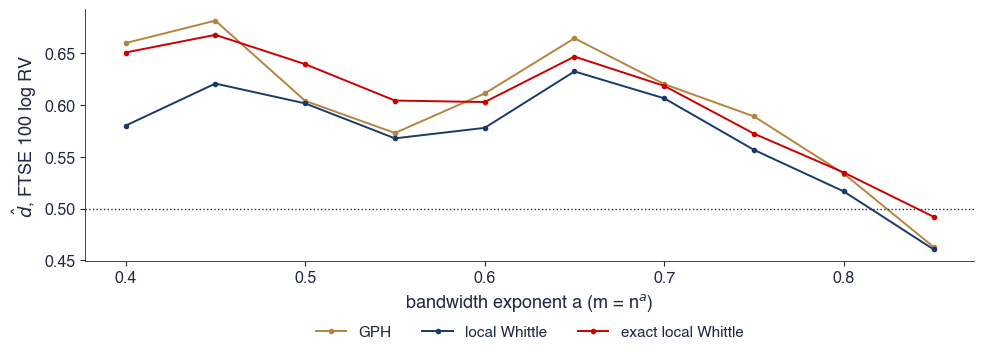

{'0.5': {'m': 74, 'gph': 0.6038665030509591, 'se_g': 0.07454669466380158, 'lw': 0.6013878129571582, 'elw': 0.6392090970406623, 'se': np.float64(0.05812381937190964)}, '0.6': {'m': 177, 'gph': 0.6109401772807072, 'se_g': 0.04820117427784339, 'lw': 0.5777921039955827, 'elw': 0.6026814339164718, 'se': np.float64(0.037582301400141446)}, '0.7': {'m': 419, 'gph': 0.6199144592718325, 'se_g': 0.031328329677193185, 'lw': 0.6062518459526525, 'elw': 0.6182531814186927, 'se': np.float64(0.024426598437301574)}}
0.33286178663159666 {'0.9': 1.089403671790751, '0.95': 1.218153631241267, '0.99': 1.5596071325332495}


In [15]:
# Solution
r = b1_ftse(save_it=False)
print(r['tab'])
print(r['W'], r['crit'])

**Interpretation of the result.** d is about 0.6 at every bandwidth and the Qu test does not reject: genuine long memory at the stationarity border.

## B2 [Proposed]: BET and EUR/RON with the Qu test

**Question.** Is the memory of |r| genuine or due to regime changes? Model: B1.

1. Local Whittle d of |r|, full sample and after the cut date.
2. The Qu statistic on the same samples.
3. Interpretation.

**Report:** four estimates with SEs, four statistics, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: roughness of the Euro Stoxx 50

**Question.** Does the GJR scaling hold, and how rough is the volatility?

1. m(q, Delta), zeta_q and H.
2. H with the error intercept.
3. H on the two halves.
4. Interpretation: is zeta_q linear?

**Report:** five slopes, three values of H, nu, one sentence.

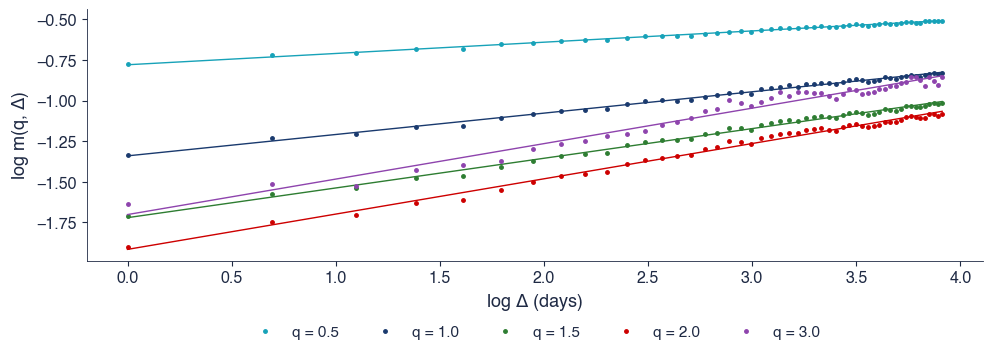

{'n': 5635, 'zeta': [0.06945211549323542, 0.13155523543904765, 0.1828368398053082, 0.2172920503329753, 0.21842734289469068], 'H': 0.0927516777117364, 'nu': 0.3836352120087559, 'Hn': 0.1086460251372105, 'share': 2.3006182282353353e-10, 'H1': 0.09126375531934526, 'H2': 0.09478667567898433, 'c': 0.6296113105323136}


In [17]:
# Solution
print(b3_stoxx(save_it=False))

**Interpretation of the result.** zeta_q is linear up to q = 2 and flat afterwards (heavy tails); H is about 0.1 and stable.

## B4 [Proposed]: Bitcoin roughness by sampling interval

**Question.** Does H depend on the sampling interval of RV? Model: B3.

1. H for RV from 1, 5, 15, 30, 60 minutes, with and without the intercept.
2. Local Whittle d.
3. Interpretation.

**Report:** ten values of H, five values of d, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: forecasting FTSE 100 realised variance

**Question.** Does a rough or a long-memory model beat HAR?

1. Forecasts of HAR, ARFIMA and RFSV.
2. QLIKE and ratios to HAR.
3. DM statistics.
4. Interpretation: which model at each horizon?

**Report:** nine losses, six ratios, six DM statistics, one sentence.

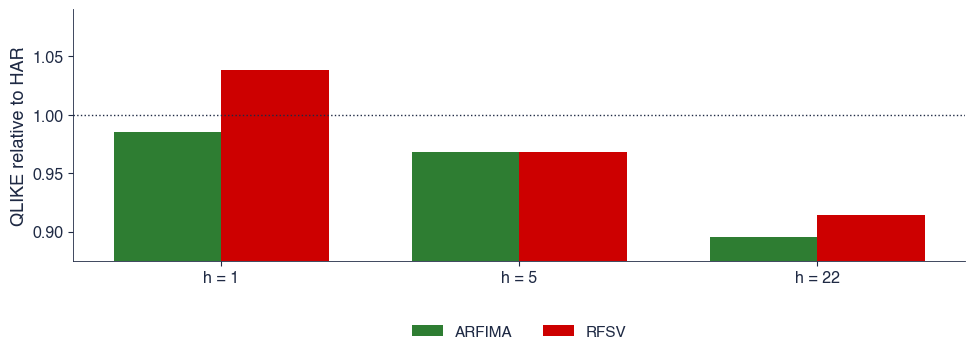

{'1': {'arf': (0.985, -0.98), 'rfsv': (1.038, 1.49)}, '5': {'arf': (0.968, -1.94), 'rfsv': (0.968, -1.33)}, '22': {'arf': (0.895, -2.12), 'rfsv': (0.914, -1.93)}}


In [19]:
# Solution
r = b5_ftse_forecast(save_it=False)
print({h: {m: (round(e[m]['rel_q'], 3), round(e[m]['dm_q'][0], 2)) for m in ('arf', 'rfsv')} for h, e in r['eval'].items()})

**Interpretation of the result.** HAR at one day; at 22 days ARFIMA and RFSV beat HAR by about a tenth.

## B6 [Proposed]: forecasting CAC 40 realised variance

**Question.** Does the FTSE 100 ranking carry over? Model: B5.

1. The three forecasts and QLIKE ratios.
2. DM statistics.
3. Interpretation.

**Report:** six ratios, six DM statistics, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: co-memory of DAX and CAC 40 volatility

**Question.** Do the volatilities of two neighbouring markets share one fractional trend? Model: B1.

1. A five-line pre-registration.
2. Local Whittle d of each series and of the spread; FCVAR with trace tests.
3. Interpretation.

**Report:** a five-line plan, five estimates, two tests, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) an ARFIMA with d = 0.3 has autocorrelations that decay exponentially, only more slowly than an AR(1);
- (b) the standard error of local Whittle is pi/sqrt(24m);
- (c) a larger bandwidth m is always better, because the variance falls;
- (d) if the Qu test rejects, the series has structural breaks;
- (e) H = 0.1 means that volatility has short memory, because H < 0.5 is antipersistence;
- (f) FIGARCH with 0 < d < 1 is covariance stationary with a finite unconditional variance;
- (g) exact local Whittle remains consistent for d = 1.2, whereas local Whittle does not.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
